In [ ]:
####################################################################
# Exercise 1
####################################################################
# PROBLEM:
# Analyze short-term residential real estate market trends in Bengaluru using NumPy for numerical analysis and Pandas for data management, then create a comprehensive visualization dashboard.

# TASKS:

# 1. Create Real Estate Dataset (90 days):
#    - Date: Daily dates for 90 consecutive days
#    - Price_High: Random floats ₹80–₹180 lakh (highest listed price per day)
#    - Price_Low: Random floats ₹40–₹95 lakh (always < Price_High)
#    - Avg_Price_per_sqft: Random floats ₹4,000–₹15,000
#    - Units_Listed: Random integers 30–220 per day
#    - Units_Sold: Random integers 5–120 per day (always ≤ Units_Listed)
#    - Home_Loan_Rate: Random floats 8.2–9.8 (%)

#    Store in Pandas DataFrame

# 2. Feature Engineering with Pandas:
#    - Add 'Price_Range' column (High - Low)
#    - Add 'Price_Avg' column ((High + Low) / 2)
#    - Add 'Month' column extracted from Date
#    - Add 'High_Demand_Day' boolean column (True if Units_Sold / Units_Listed ≥ 0.6)
#    - Add 'Market_Segment' based on avg price and demand:
#      * 'Premium_High_Demand': avg > ₹120L and high demand
#      * 'Premium_Low_Demand': avg > ₹120L and low demand
#      * 'Mid_Market_High_Demand': ₹70L–₹120L and high demand
#      * 'Mid_Market_Low_Demand': ₹70L–₹120L and low demand
#      * 'Affordable': avg < ₹70L

# 3. NumPy Statistical Analysis:
#    - Convert Price_High, Price_Low, Units_Listed, Units_Sold to 2D NumPy array
#    - Calculate correlation matrix between all variables
#    - Compute 7-day rolling mean for average prices (use NumPy)
#    - Identify price anomalies (days where high price > mean + 2*std)


# 4. Create Visualization Dashboard:
#    - Plot 1: Line plot of daily high/low prices with trend line (Matplotlib)
#    - Plot 2: Bar chart of total monthly units sold (Matplotlib)
#    - Plot 3: Scatter plot of Avg_Price_per_sqft vs Units_Sold colored by High_Demand_Day (Seaborn)
#    - Plot 4: Histogram of price range distribution (Matplotlib)
#    - Plot 5: Box plot of average prices by month (Seaborn)
#    - Plot 6: Count plot of market segments (Seaborn)
#    - Plot 7: Violin plot of units sold by market segment (Seaborn)


# Your code here:


In [12]:
# Create Real Estate Dataset (90 days):
#    - Date: Daily dates for 90 consecutive days
#    - Price_High: Random floats ₹80–₹180 lakh (highest listed price per day)
#    - Price_Low: Random floats ₹40–₹95 lakh (always < Price_High)
#    - Avg_Price_per_sqft: Random floats ₹4,000–₹15,000
#    - Units_Listed: Random integers 30–220 per day
#    - Units_Sold: Random integers 5–120 per day (always ≤ Units_Listed)
#    - Home_Loan_Rate: Random floats 8.2–9.8 (%)

from datetime import datetime, timedelta
import  random
import pandas as pd
def generateDataset(days = 90):
    startDate = datetime(2024,1,1)
    dateli =[] 
    for i in range(days+1):
        li=[]
        current_date  = (startDate + timedelta(days=i) ).strftime("%Y-%m-%d") 
        li.append(current_date) 
        highprice = round(random.uniform(8000000 , 18000000),2)
        li.append(highprice) 
        lowprice = round(random.uniform(4000000 , 9500000),2)
        li.append(lowprice)
        avg = round(random.uniform(4000 , 15000),2)
        li.append(lowprice)
        ul = random.randint(30 , 220)
        li.append(ul)
        us = random.randint(2 , 120)
        li.append(us)
        loan = round(random.uniform(8.2 , 9.8),2)
        li.append(loan)

        dateli.append(li)
         
    return dateli

Raw = generateDataset()
# print(Raw)

Rawdata = pd.DataFrame(Raw , columns=["Date","HighPrice","LowPrice","SqftAvg","UnitListed","UnitSold","HomeLoanRate"])
print(Rawdata)


          Date    HighPrice    LowPrice     SqftAvg  UnitListed  UnitSold  \
0   2024-01-01  13742351.81  7825301.66  7825301.66         123        79   
1   2024-01-02  12927212.56  7701019.73  7701019.73         151        48   
2   2024-01-03  13613291.35  5140868.21  5140868.21         173        36   
3   2024-01-04  17383486.61  4747721.61  4747721.61         152        12   
4   2024-01-05  14995884.64  6002632.08  6002632.08          39        38   
..         ...          ...         ...         ...         ...       ...   
86  2024-03-27  13707595.36  4178348.89  4178348.89         101        35   
87  2024-03-28  15837465.12  9021348.90  9021348.90         161        63   
88  2024-03-29   9406267.55  6780731.89  6780731.89         184        42   
89  2024-03-30  15269178.87  4989522.96  4989522.96         118        27   
90  2024-03-31  10881433.02  6737794.27  6737794.27         174        44   

    HomeLoanRate  
0           9.22  
1           8.60  
2           8.71  

In [13]:
#2. Feature Engineering with Pandas:
#    - Add 'Price_Range' column (High - Low)
#    - Add 'Price_Avg' column ((High + Low) / 2)
#    - Add 'Month' column extracted from Date
#    - Add 'High_Demand_Day' boolean column (True if Units_Sold / Units_Listed ≥ 0.6)
#    - Add 'Market_Segment' based on avg price and demand:
#      * 'Premium_High_Demand': avg > ₹120L and high demand
#      * 'Premium_Low_Demand': avg > ₹120L and low demand
#      * 'Mid_Market_High_Demand': ₹70L–₹120L and high demand
#      * 'Mid_Market_Low_Demand': ₹70L–₹120L and low demand
#      * 'Affordable': avg < ₹70L
import numpy as np
Rawdata["PriceRange"] = Rawdata["HighPrice"] - Rawdata["LowPrice"]

Rawdata = Rawdata.assign( AvgPrice = round(((Rawdata["HighPrice"] + Rawdata["LowPrice"]) /2) ,2)
                          , Month = pd.to_datetime(Rawdata["Date"]).dt.month_name()
                          ,HighDemandDay = round(((Rawdata["UnitSold"] + Rawdata["UnitListed"]) /2) ,2)>=6.0
                          )



conditions = [
    (Rawdata["AvgPrice"] > 120) & (Rawdata["HighDemandDay"] == True),
    (Rawdata["AvgPrice"] > 120) & (Rawdata["HighDemandDay"] == False),

    (Rawdata["AvgPrice"].between(70, 120)) & (Rawdata["HighDemandDay"] == True),
    (Rawdata["AvgPrice"].between(70, 120)) & (Rawdata["HighDemandDay"] == False),

    (Rawdata["AvgPrice"] < 70)
]

choices = [
    "Premium_High_Demand",
    "Premium_Low_Demand",
    "Mid_Market_High_Demand",
    "Mid_Market_Low_Demand",
    "Affordable"
]
Rawdata["MarketSegment"] = np.select(conditions, choices,
    default="Unknown")



Rawdata

,Date,HighPrice,LowPrice,SqftAvg,UnitListed,UnitSold,HomeLoanRate,PriceRange,AvgPrice,Month,HighDemandDay,MarketSegment
0,2024-01-01,13742351.81,7825301.66,7825301.66,123,79,9.22,5917050.15,10783826.74,January,True,Premium_High_Demand
1,2024-01-02,12927212.56,7701019.73,7701019.73,151,48,8.60,5226192.83,10314116.14,January,True,Premium_High_Demand
2,2024-01-03,13613291.35,5140868.21,5140868.21,173,36,8.71,8472423.14,9377079.78,January,True,Premium_High_Demand
3,2024-01-04,17383486.61,4747721.61,4747721.61,152,12,9.52,12635765.00,11065604.11,January,True,Premium_High_Demand
4,2024-01-05,14995884.64,6002632.08,6002632.08,39,38,8.68,8993252.56,10499258.36,January,True,Premium_High_Demand
...,...,...,...,...,...,...,...,...,...,...,...,...
86,2024-03-27,13707595.36,4178348.89,4178348.89,101,35,9.53,9529246.47,8942972.12,March,True,Premium_High_Demand
87,2024-03-28,15837465.12,9021348.90,9021348.90,161,63,8.83,6816116.22,12429407.01,March,True,Premium_High_Demand
88,2024-03-29,9406267.55,6780731.89,6780731.89,184,42,9.39,2625535.66,8093499.72,March,True,Premium_High_Demand
89,2024-03-30,15269178.87,4989522.96,4989522.96,118,27,8.42,10279655.91,10129350.91,March,True,Premium_High_Demand


In [14]:
#3. NumPy Statistical Analysis:
#    - Convert Price_High, Price_Low, Units_Listed, Units_Sold to 2D NumPy array
#    - Calculate correlation matrix between all variables
#    - Compute 7-day rolling mean for average prices (use NumPy)
#    - Identify price anomalies (days where high price > mean + 2*std)

num_array = Rawdata[["HighPrice","LowPrice","UnitListed","UnitSold"]].to_numpy()
 
np.set_printoptions(suppress=True)
print(num_array  )

corr_matrix = np.corrcoef(num_array, rowvar=False)

print(corr_matrix)


numpyavg = Rawdata["AvgPrice"].to_numpy() 
 
window = np.ones(7) / 7
rolling_mean_7d = np.convolve(numpyavg, window, mode="valid")
rolling_mean_7d 
Rawdata["AvgPrice_7DayMean"] = np.nan
Rawdata.loc[6:, "AvgPrice_7DayMean"] = rolling_mean_7d

price_high = Rawdata["HighPrice"].to_numpy() 
mean_price = np.mean(price_high)
std_price = np.std(price_high)
threshold = mean_price + 2 * std_price
anomaly_mask = price_high > threshold
price_anomalies = Rawdata[anomaly_mask]
print(price_anomalies[["Date", "HighPrice"]])

labels = ["HighPrice", "LowPrice", "UnitListed", "UnitSold"]

corr_df = pd.DataFrame(
    corr_matrix,
    index=labels,
    columns=labels
)

[[13742351.81  7825301.66      123.         79.  ]
 [12927212.56  7701019.73      151.         48.  ]
 [13613291.35  5140868.21      173.         36.  ]
 [17383486.61  4747721.61      152.         12.  ]
 [14995884.64  6002632.08       39.         38.  ]
 [15669804.99  7777582.81       75.         68.  ]
 [16845611.27  8113436.31       76.          3.  ]
 [ 8154219.09  7359495.06       42.         51.  ]
 [13203796.33  9088664.94       80.         13.  ]
 [ 9645129.54  6302085.69       53.         27.  ]
 [14552559.37  5804120.19      130.         45.  ]
 [16741849.68  8926922.63      112.         65.  ]
 [17802654.71  7069809.76       87.         11.  ]
 [12369370.78  9107029.52      108.        117.  ]
 [ 9321991.74  4405382.79      220.         93.  ]
 [13472389.72  6046194.96       80.        116.  ]
 [16371292.7   7031217.96      176.         66.  ]
 [13978338.29  5127670.91       70.         99.  ]
 [16579603.89  7149336.66       64.         65.  ]
 [17169062.55  5810067.63      

In [ ]:
# 4. Create Visualization Dashboard:
#    - Plot 1: Line plot of daily high/low prices with trend line (Matplotlib)
#    - Plot 2: Bar chart of total monthly units sold (Matplotlib)
#    - Plot 3: Scatter plot of Avg_Price_per_sqft vs Units_Sold colored by High_Demand_Day (Seaborn)
#    - Plot 4: Histogram of price range distribution (Matplotlib)
#    - Plot 5: Box plot of average prices by month (Seaborn)
#    - Plot 6: Count plot of market segments (Seaborn)
#    - Plot 7: Violin plot of units sold by market segment (Seaborn)


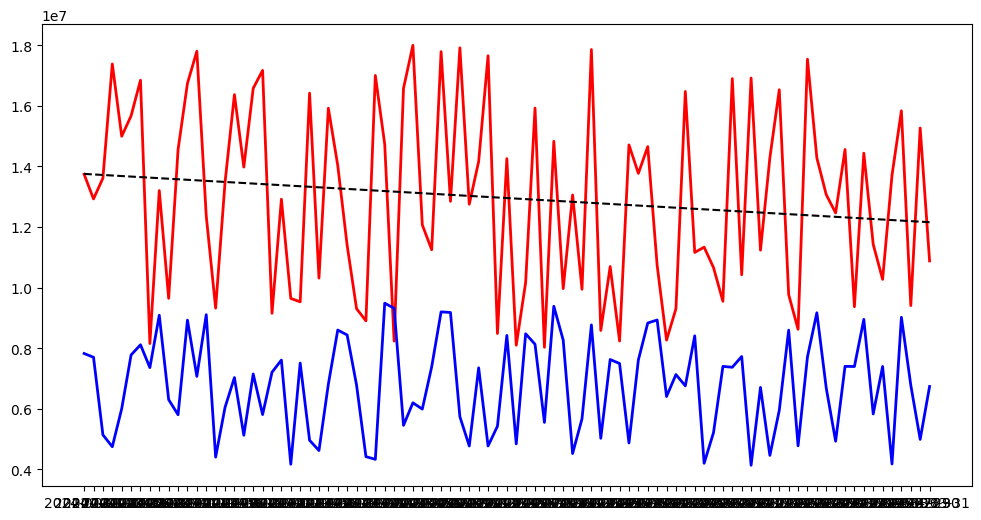

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


dates = Rawdata["Date"]
high = Rawdata["HighPrice"]
low = Rawdata["LowPrice"]

plt.figure(figsize=(12, 6))

plt.plot(dates, high, label="High Price", color="red", linewidth=2)
plt.plot(dates, low, label="Low Price", color="blue", linewidth=2)

x = np.arange(len(high))    
z = np.polyfit(x, high, 1) 
trend = np.poly1d(z)

plt.plot(dates, trend(x), linestyle="--", color="black", label="Trend Line")


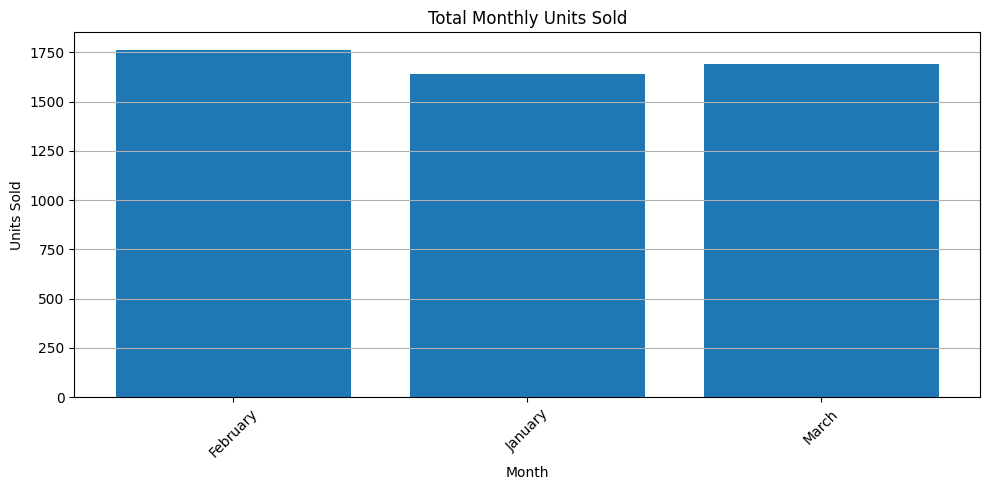

In [18]:
monthly_units = Rawdata.groupby("Month")["UnitSold"].sum()
plt.figure(figsize=(10, 5))
plt.bar(monthly_units.index, monthly_units.values)

plt.title("Total Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()